In [3]:


import pandas as pd
import numpy as np
from pathlib import Path
from catboost import CatBoostRegressor, CatBoostClassifier, Pool
from sklearn.metrics import mean_absolute_error, roc_auc_score, average_precision_score, confusion_matrix


In [8]:
MERGED = Path("/Users/aniruddh/capstone_fall25/ai-mill-tool/models/AL_LaneOne_Merged_inner.csv")
df = pd.read_csv(MERGED, low_memory=False)

In [12]:
for c in ["Mill Ready Dt","Ship Date","Delivered Date","CallReadyDate","PickUpDate","DeliveredDate"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Choose consistent date columns per legend
ready_col = "Mill Ready Dt" if "Mill Ready Dt" in df.columns else "CallReadyDate"
ship_col  = "Ship Date"      if "Ship Date"      in df.columns else "PickUpDate"
delv_col  = "Delivered Date" if "Delivered Date" in df.columns else "DeliveredDate"

# Labels in days
df["r2s_days"]  = (df[ship_col] - df[ready_col]).dt.days
df["transit_days"] = (df[delv_col] - df[ship_col]).dt.days
df["cycle_days"]   = (df[delv_col] - df[ready_col]).dt.days

# Filter to valid rows for transit prediction
data = df.dropna(subset=[ship_col, delv_col, "transit_days"]).copy()
data = data[(data["transit_days"] >= 0) & (data["transit_days"] < 45)]  # cap long-tail outliers (tune if needed)

# We'll use ship date as the split anchor (features must be known at Ship)
date_col = ship_col

In [18]:
chron = data.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

# ~60/20/20 by time quantiles
t1 = chron[date_col].quantile(0.60)
t2 = chron[date_col].quantile(0.80)

train = chron[chron[date_col] <= t1].copy()
val   = chron[(chron[date_col] >  t1) & (chron[date_col] <= t2)].copy()
test  = chron[chron[date_col] >  t2].copy()

print(train.shape, val.shape, test.shape)
print(train[date_col].min(), "→", train[date_col].max())
print(val[date_col].min(),   "→", val[date_col].max())
print(test[date_col].min(),  "→", test[date_col].max())


(5482, 69) (1835, 69) (1781, 69)
2025-01-02 00:00:00 → 2025-05-19 00:00:00
2025-05-20 00:00:00 → 2025-07-16 00:00:00
2025-07-17 00:00:00 → 2025-08-29 00:00:00


In [22]:
cat_cols = [c for c in [
    "Type of Shipment",           # F / V / LTL
    "Pickup State","Consignee State",
    "OriginST","DestST",          # if you prefer AL-side fields
    "Mill","CustomerName"
] if c in train.columns]

num_cols = [c for c in [
    "Miles/Class",                # if present and planned
    "BF","ConvBF"                 # volume proxy
] if c in train.columns]

# Calendar features from Ship Date (no leakage)
for d in (train, val, test):
    d["ShipYear"]  = d[date_col].dt.year
    d["ShipMonth"] = d[date_col].dt.month
    d["ShipDow"]   = d[date_col].dt.dayofweek
num_cols += ["ShipYear","ShipMonth","ShipDow"]

use_cols = cat_cols + num_cols
target_reg = "transit_days"

In [26]:
# CatBoost needs categoricals as strings (no NaN)
for _df in (train, val, test):
    if cat_cols:
        _df[cat_cols] = _df[cat_cols].fillna("__NA__").astype(str)
    # ensure numeric dtypes are numeric
    for c in num_cols:
        _df[c] = pd.to_numeric(_df[c], errors="coerce")
    # fill numeric NAs with group medians or global median
    _df[num_cols] = _df[num_cols].fillna(_df[num_cols].median())

cat_idx = [i for i, c in enumerate(use_cols) if c in cat_cols]

In [28]:
train_pool = Pool(train[use_cols], label=train[target_reg], cat_features=cat_idx)
val_pool   = Pool(val[use_cols],   label=val[target_reg],   cat_features=cat_idx)
test_pool  = Pool(test[use_cols],  label=test[target_reg],  cat_features=cat_idx)

cb_eta = CatBoostRegressor(
    loss_function="MAE",
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=8.0,
    subsample=0.8,
    rsm=0.8,
    iterations=8000,
    od_type="Iter",
    od_wait=300,
    random_seed=42,
    verbose=200
)
cb_eta.fit(train_pool, eval_set=val_pool)

val_p50  = cb_eta.predict(val_pool)
test_p50 = cb_eta.predict(test_pool)
print("Transit P50 MAE – Val:", mean_absolute_error(val[target_reg],  val_p50))
print("Transit P50 MAE – Test:", mean_absolute_error(test[target_reg], test_p50))

0:	learn: 0.5766504	test: 0.5849587	best: 0.5849587 (0)	total: 61.3ms	remaining: 8m 10s
200:	learn: 0.2497532	test: 0.3474394	best: 0.3445120 (163)	total: 552ms	remaining: 21.4s
400:	learn: 0.2314286	test: 0.3595554	best: 0.3445120 (163)	total: 1.17s	remaining: 22.1s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.3445120132
bestIteration = 163

Shrink model to first 164 iterations.
Transit P50 MAE – Val: 0.34451260114850296
Transit P50 MAE – Test: 0.2979907742731569


In [32]:
cb_eta_p80 = CatBoostRegressor(
    loss_function="Quantile:alpha=0.8",
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=8.0,
    subsample=0.8,
    rsm=0.8,
    iterations=8000,
    od_type="Iter",
    od_wait=300,
    random_seed=43,
    verbose=200
)
cb_eta_p80.fit(train_pool, eval_set=val_pool)

val_p80  = cb_eta_p80.predict(val_pool)
test_p80 = cb_eta_p80.predict(test_pool)

0:	learn: 0.3829840	test: 0.3998634	best: 0.3998634 (0)	total: 9.48ms	remaining: 1m 15s
200:	learn: 0.1296609	test: 0.1906975	best: 0.1853507 (77)	total: 555ms	remaining: 21.5s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.1853507218
bestIteration = 77

Shrink model to first 78 iterations.


In [36]:
lane_cols = [c for c in ["Pickup State","Consignee State","Type of Shipment"] if c in train.columns]
def _safe_key(df, cols):
    k = df[cols].copy()
    for c in cols: k[c] = k[c].astype(str).fillna("__NA__")
    return k

train_key = _safe_key(train, lane_cols) if lane_cols else None

if lane_cols:
    lane_p80 = pd.concat([train_key, train[[target_reg]]], axis=1) \
                  .groupby(lane_cols)[target_reg].quantile(0.8) \
                  .rename("lane_p80")
else:
    lane_p80 = pd.Series(dtype=float)

# attach SLA to each split (fallback to global p80 if lane missing)
global_p80 = float(train[target_reg].quantile(0.8))

def attach_sla(df):
    if lane_cols:
        k = _safe_key(df, lane_cols)
        sla = k.merge(lane_p80, left_on=lane_cols, right_index=True, how="left")["lane_p80"].fillna(global_p80)
        return sla.values
    return np.full(len(df), global_p80, dtype=float)

train["SLA_days"] = attach_sla(train)
val["SLA_days"]   = attach_sla(val)
test["SLA_days"]  = attach_sla(test)

for d in (train, val, test):
    d["on_time"] = (d[target_reg] <= d["SLA_days"]).astype(int)

# Classifier features: reuse use_cols
for _df in (train, val, test):
    # ensure same preprocessing as before (already done in D)
    pass

clf = CatBoostClassifier(
    loss_function="Logloss",
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=8.0,
    subsample=0.8,
    rsm=0.8,
    iterations=10000,
    od_type="Iter",
    od_wait=400,
    random_seed=44,
    verbose=200
)

train_pool_clf = Pool(train[use_cols], label=train["on_time"], cat_features=cat_idx)
val_pool_clf   = Pool(val[use_cols],   label=val["on_time"],   cat_features=cat_idx)
test_pool_clf  = Pool(test[use_cols],  label=test["on_time"],  cat_features=cat_idx)

clf.fit(train_pool_clf, eval_set=val_pool_clf)

val_prob  = clf.predict_proba(val[use_cols])[:,1]
test_prob = clf.predict_proba(test[use_cols])[:,1]

0:	learn: 0.6288946	test: 0.6341547	best: 0.6341547 (0)	total: 2.76ms	remaining: 27.6s
200:	learn: 0.1008362	test: 0.3058589	best: 0.2853193 (31)	total: 737ms	remaining: 35.9s
400:	learn: 0.0670696	test: 0.3161270	best: 0.2853193 (31)	total: 1.53s	remaining: 36.6s
Stopped by overfitting detector  (400 iterations wait)

bestTest = 0.2853193393
bestIteration = 31

Shrink model to first 32 iterations.


In [40]:

print("On-time AUC – Val:",  roc_auc_score(val["on_time"],  val_prob))
print("On-time AUC – Test:", roc_auc_score(test["on_time"], test_prob))
print("On-time AUPRC – Val:",  average_precision_score(val["on_time"],  val_prob))
print("On-time AUPRC – Test:", average_precision_score(test["on_time"], test_prob))

# Choose a business threshold: e.g., flag as 'at-risk' if P(on-time) < 0.7
thr = 0.7
test_pred_atrisk = (test_prob < thr).astype(int)  # 1 = at-risk (late)
cm = confusion_matrix(test["on_time"]==0, test_pred_atrisk)  # treat 'late' as positive
cm

On-time AUC – Val: 0.8375234385594112
On-time AUC – Test: 0.8952647425480287
On-time AUPRC – Val: 0.9605766971465792
On-time AUPRC – Test: 0.9777771548292309


array([[1519,   30],
       [  89,  143]])

In [48]:
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc, confusion_matrix,
    mean_absolute_error
)

import matplotlib.pyplot as plt

In [52]:
cb_eta_dbg = CatBoostRegressor(
    loss_function="MAE",      # or Quantile:alpha=0.5 (see §3)
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=8.0,
    subsample=0.8, rsm=0.8,
    iterations=4000,
    od_type="Iter", od_wait=800,  # give it more room to explore
    random_seed=42,
    verbose=50
)
cb_eta_dbg.fit(train_pool, eval_set=val_pool, use_best_model=False)
lc = cb_eta_dbg.get_evals_result()
# plot lc['learn']['MAE'] vs lc['validation']['MAE'] to verify plateaus


0:	learn: 0.5766504	test: 0.5849587	best: 0.5849587 (0)	total: 4.36ms	remaining: 17.4s
50:	learn: 0.2794851	test: 0.3605425	best: 0.3605425 (50)	total: 158ms	remaining: 12.2s
100:	learn: 0.2552806	test: 0.3458063	best: 0.3447420 (96)	total: 272ms	remaining: 10.5s
150:	learn: 0.2520840	test: 0.3445983	best: 0.3445485 (148)	total: 388ms	remaining: 9.89s
200:	learn: 0.2497532	test: 0.3474394	best: 0.3445120 (163)	total: 518ms	remaining: 9.78s
250:	learn: 0.2432459	test: 0.3513647	best: 0.3445120 (163)	total: 671ms	remaining: 10s
300:	learn: 0.2387051	test: 0.3552099	best: 0.3445120 (163)	total: 824ms	remaining: 10.1s
350:	learn: 0.2348576	test: 0.3559128	best: 0.3445120 (163)	total: 981ms	remaining: 10.2s
400:	learn: 0.2314286	test: 0.3595554	best: 0.3445120 (163)	total: 1.14s	remaining: 10.3s
450:	learn: 0.2281154	test: 0.3607112	best: 0.3445120 (163)	total: 1.3s	remaining: 10.3s
500:	learn: 0.2256316	test: 0.3619960	best: 0.3445120 (163)	total: 1.46s	remaining: 10.2s
550:	learn: 0.22249

In [54]:
cb_eta_long = CatBoostRegressor(
    loss_function="MAE",
    depth=10,               # a bit deeper
    learning_rate=0.02,     # smaller steps
    l2_leaf_reg=6.0,        # slightly looser
    subsample=0.85, rsm=0.9,
    iterations=20000,       # many more trees
    od_type="Iter", od_wait=1200,
    random_seed=42, verbose=200
).fit(train_pool, eval_set=val_pool)

0:	learn: 0.5868073	test: 0.5926753	best: 0.5926753 (0)	total: 3.99ms	remaining: 1m 19s
200:	learn: 0.2593537	test: 0.3494842	best: 0.3494842 (200)	total: 580ms	remaining: 57.2s
400:	learn: 0.2505347	test: 0.3463734	best: 0.3454206 (330)	total: 1.15s	remaining: 56.4s
600:	learn: 0.2311312	test: 0.3607526	best: 0.3454206 (330)	total: 2.08s	remaining: 1m 7s
800:	learn: 0.2157842	test: 0.3701466	best: 0.3454206 (330)	total: 3.01s	remaining: 1m 12s
1000:	learn: 0.2019634	test: 0.3767965	best: 0.3454206 (330)	total: 3.97s	remaining: 1m 15s
1200:	learn: 0.1870133	test: 0.3826311	best: 0.3454206 (330)	total: 4.93s	remaining: 1m 17s
1400:	learn: 0.1744251	test: 0.3909976	best: 0.3454206 (330)	total: 5.88s	remaining: 1m 18s
Stopped by overfitting detector  (1200 iterations wait)

bestTest = 0.3454206196
bestIteration = 330

Shrink model to first 331 iterations.


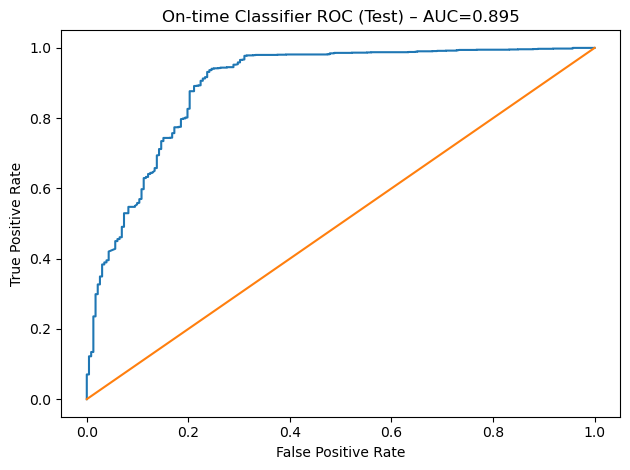

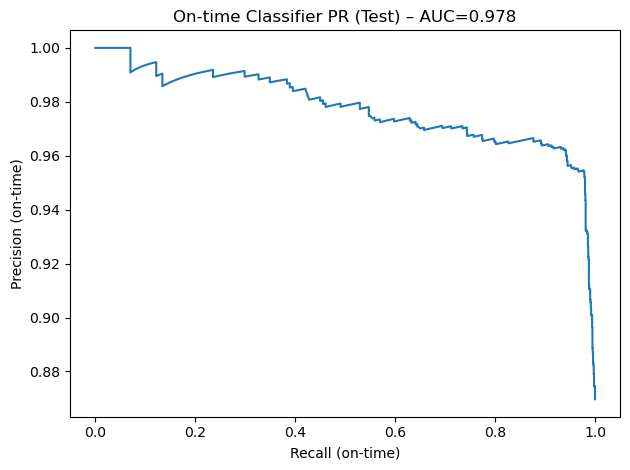

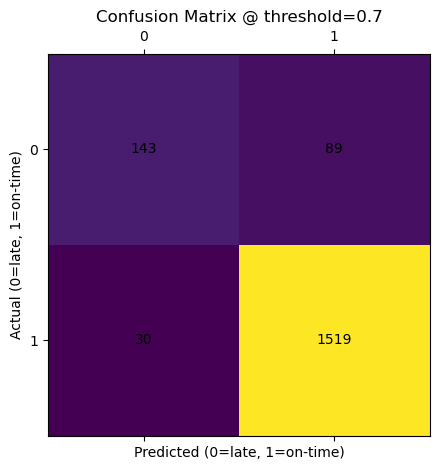

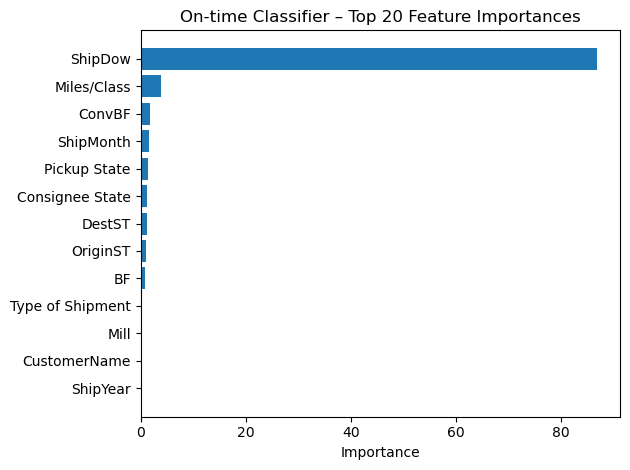

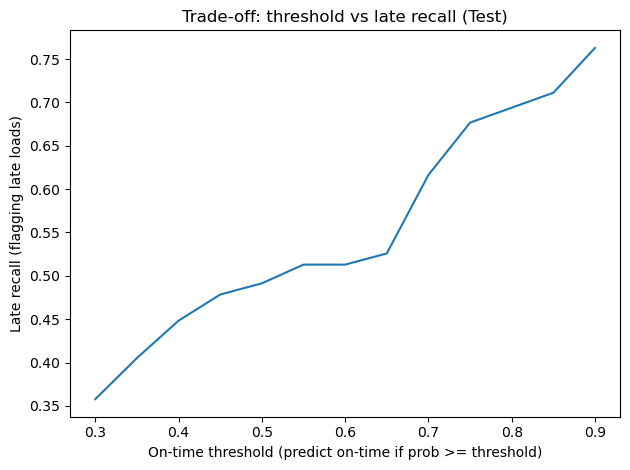

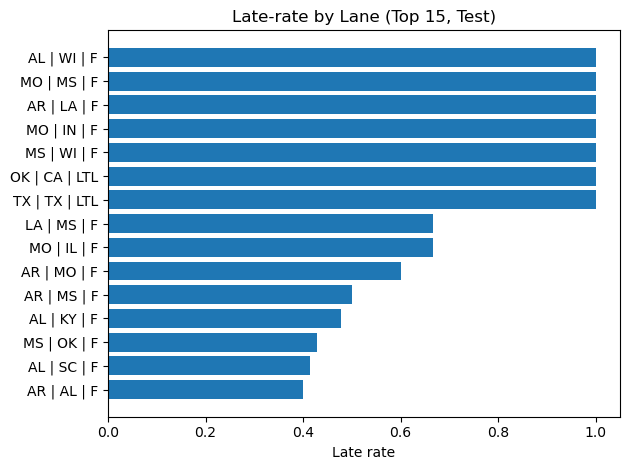

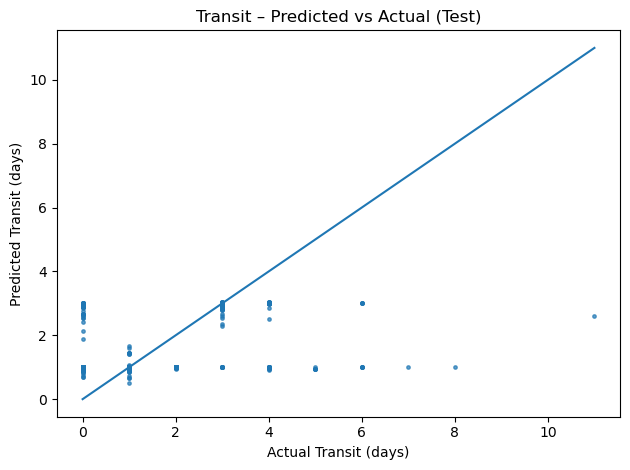

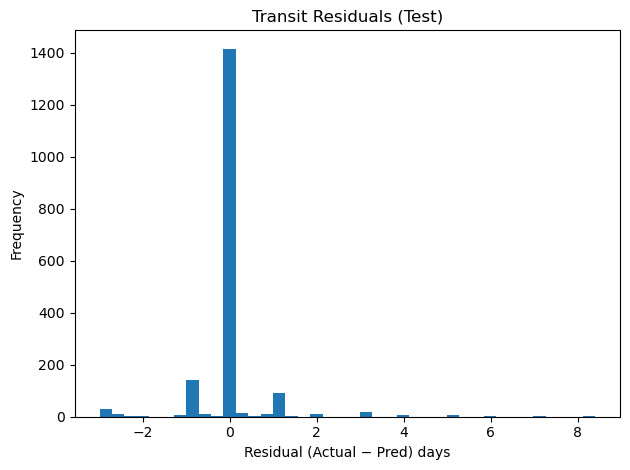

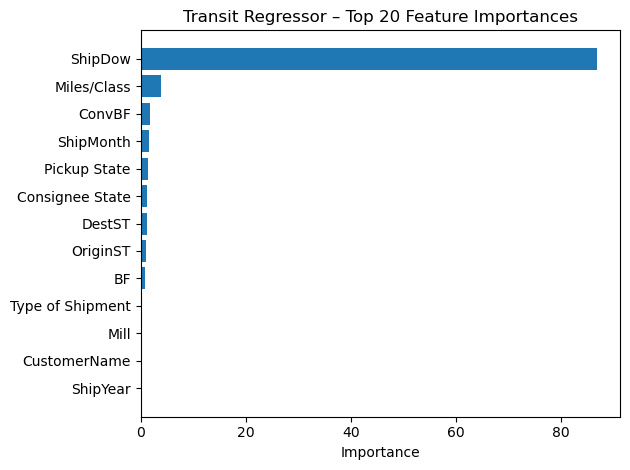

P80 coverage on Test: 0.884 (target ≈ 0.80)


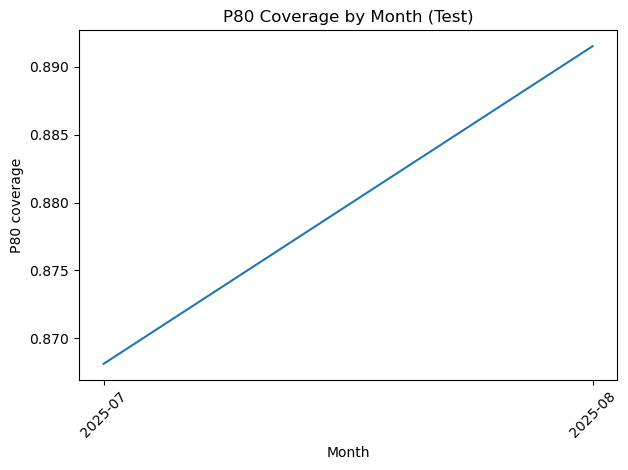

In [61]:
def _has(cols, df):
    return all(c in df.columns for c in cols)

# -----------------------------
# 1) On-time classifier metrics
# -----------------------------
assert 'clf' in globals(), "Missing classifier `clf`."
assert all(x in globals() for x in ['test','use_cols']), "Need `test` and `use_cols`."

y_true_on = test['on_time'].astype(int).values
prob_on   = clf.predict_proba(test[use_cols])[:,1]

# ROC
fpr, tpr, _ = roc_curve(y_true_on, prob_on)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"On-time Classifier ROC (Test) – AUC={roc_auc:.3f}")
plt.tight_layout()
plt.show()

# PR (positive = on-time)
prec, rec, thr = precision_recall_curve(y_true_on, prob_on)
pr_auc = auc(rec, prec)
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall (on-time)")
plt.ylabel("Precision (on-time)")
plt.title(f"On-time Classifier PR (Test) – AUC={pr_auc:.3f}")
plt.tight_layout()
plt.show()

# Confusion matrix at a business threshold
thr_on_time = 0.70  # tune this for ops
y_pred_on   = (prob_on >= thr_on_time).astype(int)  # 1 = predict on-time
cm = confusion_matrix(y_true_on, y_pred_on, labels=[0,1])  # rows: actual late/on-time
plt.figure()
plt.matshow(cm, fignum=0)
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.xlabel("Predicted (0=late, 1=on-time)")
plt.ylabel("Actual (0=late, 1=on-time)")
plt.title(f"Confusion Matrix @ threshold={thr_on_time}")
plt.tight_layout()
plt.show()

# Feature importance (classifier)
imp_clf = cb_eta_long.get_feature_importance(type="FeatureImportance")
fi_clf  = (pd.DataFrame({"feature": use_cols, "importance": imp_clf})
             .sort_values("importance", ascending=False)
             .head(20))
plt.figure()
plt.barh(range(len(fi_clf)), fi_clf["importance"].values[::-1])
plt.yticks(range(len(fi_clf)), fi_clf["feature"].values[::-1])
plt.xlabel("Importance")
plt.title("On-time Classifier – Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# Threshold sweep table (business tuning)
rows = []
for t in np.linspace(0.30, 0.90, 13):
    y_hat_on = (prob_on >= t).astype(int)
    cm_t = confusion_matrix(y_true_on, y_hat_on, labels=[0,1])
    tn, fp, fn, tp = cm_t.ravel()

    # Late metrics: flip orientation so late=1
    is_late   = 1 - y_true_on
    pred_late = (prob_on < t).astype(int)
    cm_l = confusion_matrix(is_late, pred_late, labels=[0,1])
    tn_l, fp_l, fn_l, tp_l = cm_l.ravel()
    late_prec = tp_l / (tp_l + fp_l) if (tp_l + fp_l) else np.nan
    late_rec  = tp_l / (tp_l + fn_l) if (tp_l + fn_l) else np.nan

    rows.append({
        "threshold_on_time": round(t,3),
        "on_time_precision": (tp/(tp+fp)) if (tp+fp) else np.nan,
        "on_time_recall":    (tp/(tp+fn)) if (tp+fn) else np.nan,
        "late_precision":    late_prec,
        "late_recall":       late_rec,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    })
th_df = pd.DataFrame(rows)
th_df

# Optional: plot late_recall vs threshold for a quick visual
plt.figure()
plt.plot(th_df["threshold_on_time"], th_df["late_recall"])
plt.xlabel("On-time threshold (predict on-time if prob >= threshold)")
plt.ylabel("Late recall (flagging late loads)")
plt.title("Trade-off: threshold vs late recall (Test)")
plt.tight_layout()
plt.show()

# Late-risk by lane (Test)
lane_cols = [c for c in ["Pickup State","Consignee State","Type of Shipment"] if c in test.columns]
if lane_cols:
    lane_tmp = test[lane_cols].copy()
    lane_tmp["is_late"] = (test["on_time"] == 0).astype(int).values
    lane_tmp["at_risk"] = (prob_on < thr_on_time).astype(int)
    lane_summary = (lane_tmp.groupby(lane_cols)
                    .agg(total=("is_late","size"),
                         late_rate=("is_late","mean"),
                         at_risk_rate=("at_risk","mean"))
                    .reset_index()
                    .sort_values(["late_rate","total"], ascending=[False, False]))
    # Top 15 lanes by late rate
    top = lane_summary.head(15)
    labels = top[lane_cols].astype(str).agg(" | ".join, axis=1).values
    plt.figure()
    plt.barh(range(len(top)), top["late_rate"].values[::-1])
    plt.yticks(range(len(top)), labels[::-1])
    plt.xlabel("Late rate")
    plt.title("Late-rate by Lane (Top 15, Test)")
    plt.tight_layout()
    plt.show()
    # Also show the table
    lane_summary.head(25)

# -----------------------------------
# 2) Transit regression visualizations
# -----------------------------------
assert 'cb_eta' in globals(), "Missing transit regressor `cb_eta`."
y_test = test["transit_days"].values
y_hat  = cb_eta_long.predict(test[use_cols])

# Predicted vs Actual
plt.figure()
plt.scatter(y_test, y_hat, s=6, alpha=0.7)
lo = float(np.nanmin([y_test.min(), y_hat.min()]))
hi = float(np.nanmax([y_test.max(), y_hat.max()]))
plt.plot([lo,hi],[lo,hi])
plt.xlabel("Actual Transit (days)")
plt.ylabel("Predicted Transit (days)")
plt.title("Transit – Predicted vs Actual (Test)")
plt.tight_layout()
plt.show()

# Residuals
resid = y_test - y_hat
plt.figure()
plt.hist(resid, bins=40)
plt.xlabel("Residual (Actual − Pred) days")
plt.ylabel("Frequency")
plt.title("Transit Residuals (Test)")
plt.tight_layout()
plt.show()

# Transit regressor feature importance (optional)
imp_eta = cb_eta_long.get_feature_importance(type="FeatureImportance")
fi_eta  = (pd.DataFrame({"feature": use_cols, "importance": imp_eta})
             .sort_values("importance", ascending=False)
             .head(20))
plt.figure()
plt.barh(range(len(fi_eta)), fi_eta["importance"].values[::-1])
plt.yticks(range(len(fi_eta)), fi_eta["feature"].values[::-1])
plt.xlabel("Importance")
plt.title("Transit Regressor – Top 20 Feature Importances")
plt.tight_layout()
plt.show()

# -----------------------------------
# 3) P80 coverage check (did we hit ~80%?)
# -----------------------------------
assert 'cb_eta_p80' in globals(), "Missing P80 quantile model `cb_eta_p80`."
p80_hat = cb_eta_p80.predict(test[use_cols])
covered = (y_test <= p80_hat).mean()
print(f"P80 coverage on Test: {covered:.3f} (target ≈ 0.80)")

# Monthly coverage plot
if date_col in test.columns:
    m = pd.to_datetime(test[date_col], errors="coerce").dt.to_period("M").astype(str)
    cov_df = pd.DataFrame({"month": m, "covered": (y_test <= p80_hat)})
    cov_sum = (cov_df.groupby("month")["covered"].mean()
                      .reset_index()
                      .sort_values("month"))
    plt.figure()
    plt.plot(cov_sum["month"].values, cov_sum["covered"].values)
    plt.xticks(rotation=45)
    plt.xlabel("Month")
    plt.ylabel("P80 coverage")
    plt.title("P80 Coverage by Month (Test)")
    plt.tight_layout()
    plt.show()

# -----------------------------------
# 4) Handy business table: top late-risk loads
# -----------------------------------
if _has(["on_time"], test):
    df_top = test.copy()
    df_top["prob_on_time"] = prob_on
    df_top["at_risk"] = (prob_on < thr_on_time).astype(int)
    show_cols = [c for c in ["Ship Date","Pickup State","Consignee State","Type of Shipment",
                             "Mill","CustomerName","Miles/Class","transit_days","prob_on_time","at_risk"] if c in df_top.columns]
    df_top = df_top[show_cols].sort_values(["at_risk","prob_on_time"]).head(25)
    df_top